In [1]:
import os
import datetime
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from torch.utils.data import Dataset, DataLoader

batch_size = 256
sequence_length = 500 # 模型查看的历史窗口大小
prediction_horizon = 1 # 预测的未来窗口大小

directory = "../datas/train" #设置数据目录
all_items = os.listdir(directory)  #列出目录下所有文件
csv_files = [os.path.join(directory, item) for item in all_items if item.endswith('.csv') and os.path.isfile(os.path.join(directory, item))]  #筛选出CSV文件 
Sample_size = len(csv_files)  #获取样本数量

sequences_data = [] #创建一个空列表，用于存储所有序列的数据
scalers = {} #创建一个空字典，用于存储每个序列对应的标准化器
base_features = ['Voltage', 'Current']
new_features = ['impedance', 'power', 'cumulative_power', 'impedance_diff', 'impedance_rolling_mean', 'impedance_rolling_std', 'impedance_slope_10']
features = base_features + new_features

for file in csv_files:
    df = pd.read_csv(file)
    df['impedance'] = df['Voltage'] * 1000 / df['Current'].replace(0, np.nan)
    df['power'] = df['Voltage'] * (df['Current'] / 1000)
    df['cumulative_power'] = (df['power']/1000).cumsum()
    #数据预处理 添加阻抗变化率特征
    df['impedance_diff'] = df['impedance'].diff().fillna(0) #添加一阶差分
    df['impedance_rolling_mean'] = df['impedance'].rolling(window=20, min_periods=1).mean() #滚动均值
    df['impedance_rolling_std'] = df['impedance'].rolling(window=20, min_periods=1).std()  #滚动标准差
    df['impedance_slope_10'] = df['impedance'].diff(10) / 10  #过去 10 个时间点的平均变化率。
    df['impedance_slope_10'] = df['impedance_slope_10'].fillna(0) # 将该列中的所有缺失值（NaN）填充为数字0
    df = df.ffill().bfill()  #缺失值处理先用前向填充，再用后向填充
    #数据预处理 数值归一化
    scaler = StandardScaler() #为当前序列创建一个新的StandardScaler实例
    df.loc[:, features] = scaler.fit_transform(df.loc[:, features]) #对当前序列的指定特征列进行拟合和转换
    scalers[file] = scaler #将当前序列的标准化器保存到字典中，键为序列ID
    sequences_data.append(df[features + ['Action']].values) #将当前序列的数组数据添加到结果列表中

train_sequences, val_sequences = train_test_split(sequences_data, test_size=0.18, random_state=42)

class MultiSequenceDataset(Dataset):
    def __init__(self, sequences_data, sequence_length=200, prediction_horizon=1): 
        self.sequences_data = sequences_data # 输入数据
        self.sequence_length = sequence_length # 模型查看的历史窗口大小
        self.prediction_horizon = prediction_horizon # 预测的未来窗口大小
        self.samples = [] #创建一个空列表
        for seq_data in sequences_data: #遍历列表里每一条训练数据数组（多维序列）
            n_samples = len(seq_data) - sequence_length - prediction_horizon + 1 #计算可以生成多少个有效样本：
            for i in range(n_samples): #将n_samples个一个元组 (seq_data, i) 添加到 self.samples 列表中。
                self.samples.append((seq_data, i)) # 生成待截取序列和开始截取的位置列表，真浪费内存。
        
    def __len__(self): 
        return len(self.samples)    #返回数据集中样本的总数，即 self.samples 列表的长度。

    def __getitem__(self, idx): 
        seq_data, start_idx = self.samples[idx] #从 self.samples 列表中取出第 idx 个样本对应的原始序列 seq_data 和起始索引 start_idx。
        x = seq_data[start_idx:start_idx + self.sequence_length, :-1]#从 start_idx 开始，截取长度为 sequence_length 的连续时间步。[:, :-1] 表示取所有这些行（时间步），但只取最后一列之前的所有列。
        y_start = start_idx + self.sequence_length #输入序列 x 结束后的下一个时间点。
        y_end = y_start + self.prediction_horizon #y_start 之后的 prediction_horizon 个时间点
        y_window = seq_data[y_start:y_end, -1] # 截取了从 y_start 到 y_end 这个未来窗口内的最后一列，也就是标签列。y_window 是一个一维数组。
        y = 1 if np.any(y_window == 1) else 0
        return torch.FloatTensor(x), torch.FloatTensor([y])

train_dataset = MultiSequenceDataset(train_sequences, sequence_length, prediction_horizon)
val_dataset = MultiSequenceDataset(val_sequences, sequence_length, prediction_horizon)
train_loader = DataLoader(train_dataset, batch_size, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size, shuffle=False)

print(f'检索到{Sample_size}个样本')
print(f"特征数量: {len(features)}")
print(f"序列数量: {len(sequences_data)}")
print(f"训练序列: {len(train_sequences)}")
print(f"验证序列: {len(val_sequences)}") 
print(f"训练样本数: {len(train_dataset)}")
print(f"验证样本数: {len(val_dataset)}")

检索到55个样本
特征数量: 9
序列数量: 55
训练序列: 45
验证序列: 10
训练样本数: 530572
验证样本数: 113211


In [2]:
import torch
import torch.nn as nn

model_name = 'MLP'

# MLP模型定义
class MLPModel(nn.Module):
    def __init__(self, input_size, hidden_sizes=[256, 128, 64], num_classes=1, dropout_rate=0.3):
        super(MLPModel, self).__init__()
        
        layers = []
        prev_size = input_size
        
        # 动态构建隐藏层
        for i, hidden_size in enumerate(hidden_sizes):
            layers.append(nn.Linear(prev_size, hidden_size))
            layers.append(nn.BatchNorm1d(hidden_size))
            layers.append(nn.ReLU())
            layers.append(nn.Dropout(dropout_rate))
            prev_size = hidden_size
        
        # 输出层
        layers.append(nn.Linear(prev_size, num_classes))
        layers.append(nn.Sigmoid())
        self.network = nn.Sequential(*layers)
        
    def forward(self, x):
        # 将输入展平: [batch_size, seq_len, features] -> [batch_size, seq_len * features]
        batch_size = x.size(0)
        x = x.view(batch_size, -1)
        return self.network(x)

# 计算输入尺寸
# sequence_length * 特征数量 (base_features + new_features 的数量)
input_features = len(features)  # 特征数量
input_size = sequence_length * input_features
hidden_sizes=[512, 256, 128, 64]

# 初始化模型
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = MLPModel(input_size, 
                 hidden_sizes, 
                 dropout_rate=0.4).to(device)
# 定义损失函数和优化器
criterion = nn.BCELoss()  # nn.BCEWithLogitsLoss()

# 训练函数
def train_epoch(model, dataloader, criterion, optimizer, device):
    model.train()
    running_loss = 0.0
    all_predictions = []
    all_labels = []
    
    for batch_idx, (data, targets) in enumerate(tqdm(dataloader, desc="已完成", ncols=60)):
        data, targets = data.to(device), targets.to(device)
        
        optimizer.zero_grad()
        
        outputs = model(data)
        loss = criterion(outputs.squeeze(), targets.squeeze())
        
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        optimizer.step()
        
        running_loss += loss.item()
        
        # 计算预测结果
        predictions = outputs.squeeze() #torch.sigmoid(outputs).squeeze()
        predicted_labels = (predictions > 0.5).float()
        
        all_predictions.extend(predicted_labels.cpu().detach().numpy())
        all_labels.extend(targets.squeeze().cpu().numpy())
        
    epoch_loss = running_loss / len(dataloader)
    accuracy = accuracy_score(all_labels, all_predictions)
    precision = precision_score(all_labels, all_predictions, zero_division=0)
    recall = recall_score(all_labels, all_predictions, zero_division=0)
    f1 = f1_score(all_labels, all_predictions, zero_division=0)
    
    return epoch_loss, accuracy, precision, recall, f1

# 验证函数
def validate_epoch(model, dataloader, criterion, device):
    model.eval()
    running_loss = 0.0
    all_predictions = []
    all_labels = []
    all_probabilities = []
    
    with torch.no_grad():
        for data, targets in dataloader:
            data, targets = data.to(device), targets.to(device)
            
            outputs = model(data)
            loss = criterion(outputs.squeeze(), targets.squeeze())
            
            running_loss += loss.item()
            
            probabilities = outputs.squeeze() # torch.sigmoid(outputs).squeeze()
            predicted_labels = (probabilities > 0.5).float()
            
            all_predictions.extend(predicted_labels.cpu().numpy())
            all_labels.extend(targets.squeeze().cpu().numpy())
            all_probabilities.extend(probabilities.cpu().numpy())
    
    epoch_loss = running_loss / len(dataloader)
    accuracy = accuracy_score(all_labels, all_predictions)
    precision = precision_score(all_labels, all_predictions, zero_division=0)
    recall = recall_score(all_labels, all_predictions, zero_division=0)
    f1 = f1_score(all_labels, all_predictions, zero_division=0)
    
    return epoch_loss, accuracy, precision, recall, f1, all_probabilities

print("=" * 80)
print(f"MLP模型配置完成")
print(f"使用设备: {device}")
# print(f"隐藏层配置: {hidden_size}")
print(f"模型参数数量: {sum(p.numel() for p in model.parameters()):,}")
print(f"输入尺寸: {input_size} (序列长度 {sequence_length} × 特征数 {input_features})")
print("=" * 80)

MLP模型配置完成
使用设备: cuda
模型参数数量: 2,478,977
输入尺寸: 4500 (序列长度 500 × 特征数 9)


In [3]:
import torch.optim as optim
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
from tqdm import tqdm
import time
from datetime import datetime

learning_rate = 0.001
num_epochs = 100
patience = 20

optimizer = optim.Adam(model.parameters(), lr=learning_rate, weight_decay=1e-4)
scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', patience=5, factor=0.5)

# 训练循环
train_losses = []
val_losses = []
train_metrics = []
val_metrics = []

best_val_f1 = 0.0
best_model_state = None
patience_counter = 0
current_lr = learning_rate

print("=" * 80)
print(f"开始训练{model_name}模型...")
print(f"使用设备: {device}")
print(f"最大训练轮数: {num_epochs}")
print(f"早停耐心值: {patience}")
print(f"初始学习率: {learning_rate}")
print("=" * 80)

for epoch in range(num_epochs):

    epoch_start_time = time.time()
    # 训练
    train_loss, train_acc, train_prec, train_rec, train_f1 = train_epoch(
        model, train_loader, criterion, optimizer, device)
    
    # 验证
    val_loss, val_acc, val_prec, val_rec, val_f1, val_probs = validate_epoch(
        model, val_loader, criterion, device)

    epoch_time = time.time() - epoch_start_time
    
    # 学习率调度
    scheduler.step(val_loss)
    if current_lr != optimizer.param_groups[0]['lr']:
        current_lr = optimizer.param_groups[0]['lr']
        print(f'*** Learning rate reduced to {current_lr:.6f} *** ')
        
    # 保存损失和指标
    train_losses.append(train_loss)
    val_losses.append(val_loss)
    train_metrics.append((train_acc, train_prec, train_rec, train_f1))
    val_metrics.append((val_acc, val_prec, val_rec, val_f1))
    
    # 保存最佳模型
    if val_f1 > best_val_f1:
        best_val_f1 = val_f1
        patience_counter = 0
        best_epoch = epoch + 1
        torch.save(model.state_dict(), f'Model_{model_name}.pkl')
        print(f'*** New best model saved! Validation F1: {val_f1:.6f} ***')
    else:
        patience_counter += 1
    
    # 打印训练信息
    print(f'Epoch [{epoch+1:3d}/{num_epochs}] | EarlyStop [{patience_counter:2d}/{patience}] Time: {epoch_time:.1f}s | LR: {current_lr:.6f}')
    print(f'Train Loss: {train_loss:.4f} | Train Acc: {train_acc:.2f}% |', end='')
    print(f' Val Loss: {val_loss:.4f} | Val Acc: {val_acc:.2f}% | Val F1: {val_f1:.6f}')
    
    # 早停
    if patience_counter >= patience:
        print(f"\n")
        break

print(f"训练完成！早停于第 {epoch+1} 轮, 最佳验证集 F1: {best_val_f1:.4f} 于第{best_epoch}轮训练", end=" ")
timestamp = datetime.now().strftime("%Y%m%d_%H%M%S")
print(f"完成时间{timestamp}")
print(f"模型已保存为 'Model_{model_name}.pkl'")

# 最终评估
print("\n最终模型在验证集上的表现:")
final_val_loss, final_val_acc, final_val_prec, final_val_rec, final_val_f1, _ = validate_epoch(
    model, val_loader, criterion, device)

print(f"验证集损失: {final_val_loss:.4f}")
print(f"验证集准确率: {final_val_acc:.4f}")
print(f"验证集精确率: {final_val_prec:.4f}")
print(f"验证集召回率: {final_val_rec:.4f}")
print(f"验证集 F1分数: {final_val_f1:.4f}")

开始训练MLP模型...
使用设备: cuda
最大训练轮数: 100
早停耐心值: 20
初始学习率: 0.001


已完成: 100%|██████████| 2073/2073 [00:12<00:00, 162.10it/s]


*** New best model saved! Validation F1: 0.929905 ***
Epoch [  1/100] | EarlyStop [ 0/20] Time: 15.4s | LR: 0.001000
Train Loss: 0.0989 | Train Acc: 0.96% | Val Loss: 0.0512 | Val Acc: 0.98% | Val F1: 0.929905


已完成: 100%|██████████| 2073/2073 [00:12<00:00, 162.67it/s]


*** New best model saved! Validation F1: 0.950922 ***
Epoch [  2/100] | EarlyStop [ 0/20] Time: 15.4s | LR: 0.001000
Train Loss: 0.0694 | Train Acc: 0.97% | Val Loss: 0.0428 | Val Acc: 0.99% | Val F1: 0.950922


...

*** Learning rate reduced to 0.000063 *** 
Epoch [ 35/100] | EarlyStop [18/20] Time: 15.2s | LR: 0.000063
Train Loss: 0.0278 | Train Acc: 0.99% | Val Loss: 0.0643 | Val Acc: 0.98% | Val F1: 0.927880


已完成: 100%|██████████| 2073/2073 [00:12<00:00, 165.54it/s]


Epoch [ 36/100] | EarlyStop [19/20] Time: 15.2s | LR: 0.000063
Train Loss: 0.0254 | Train Acc: 0.99% | Val Loss: 0.0813 | Val Acc: 0.98% | Val F1: 0.921137


已完成: 100%|██████████| 2073/2073 [00:12<00:00, 165.36it/s]


Epoch [ 37/100] | EarlyStop [20/20] Time: 15.2s | LR: 0.000063
Train Loss: 0.0242 | Train Acc: 0.99% | Val Loss: 0.0751 | Val Acc: 0.98% | Val F1: 0.931804


训练完成！早停于第 37 轮, 最佳验证集 F1: 0.9629 于第17轮训练 完成时间20251216_075049
模型已保存为 'Model_MLP.pkl'

最终模型在验证集上的表现:
验证集损失: 0.0751
验证集准确率: 0.9816
验证集精确率: 0.9970
验证集召回率: 0.8746
验证集 F1分数: 0.9318


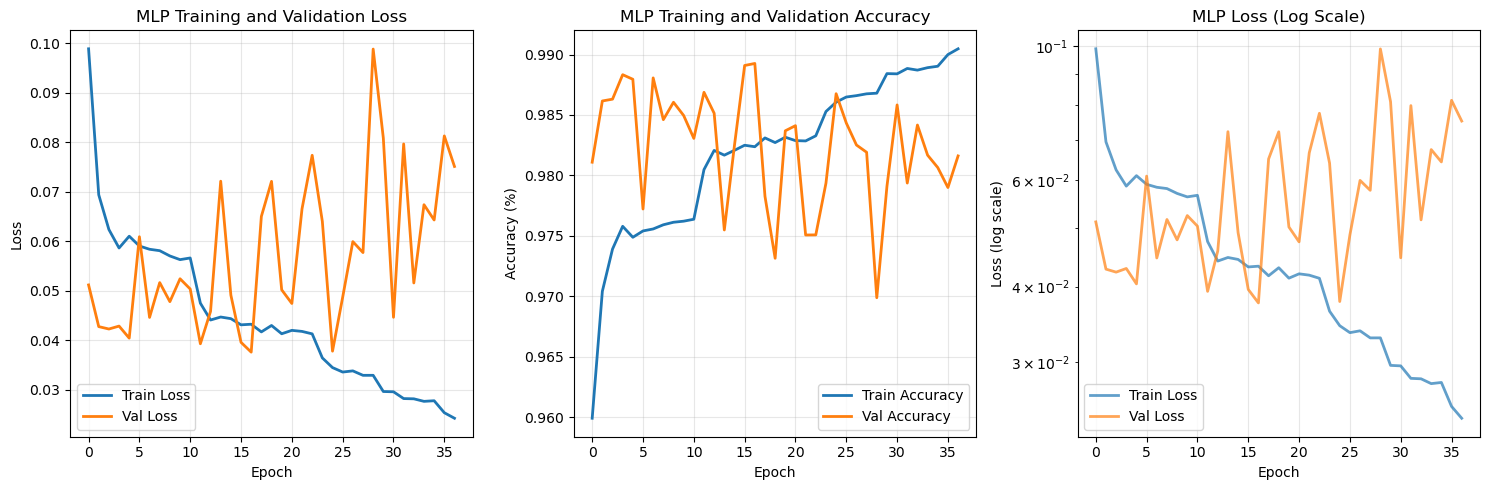

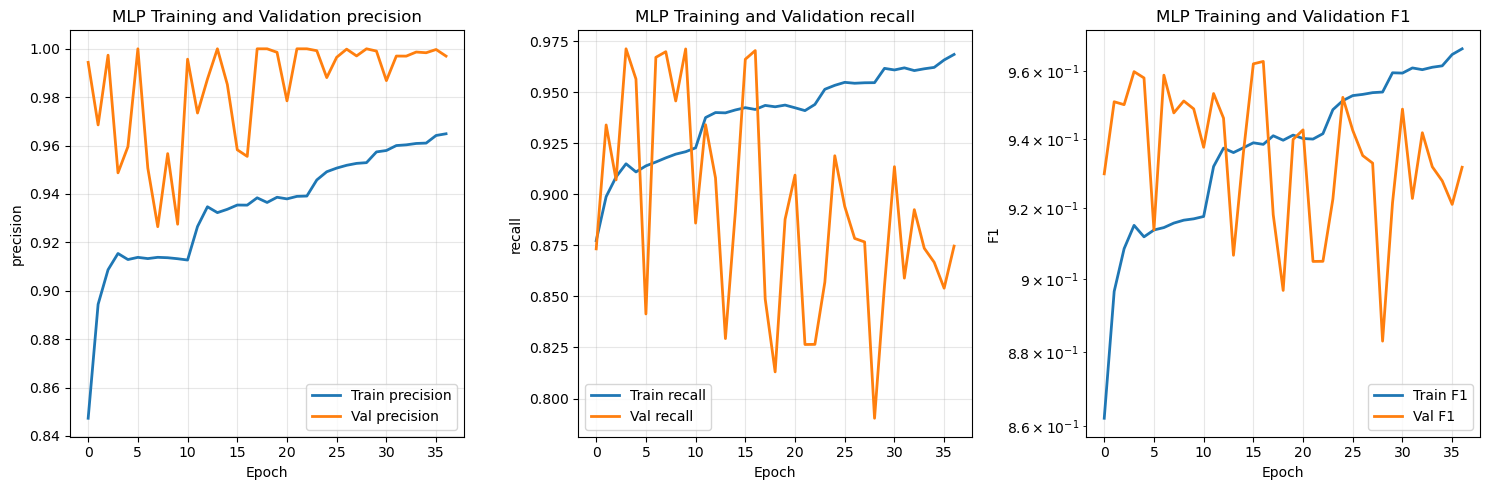

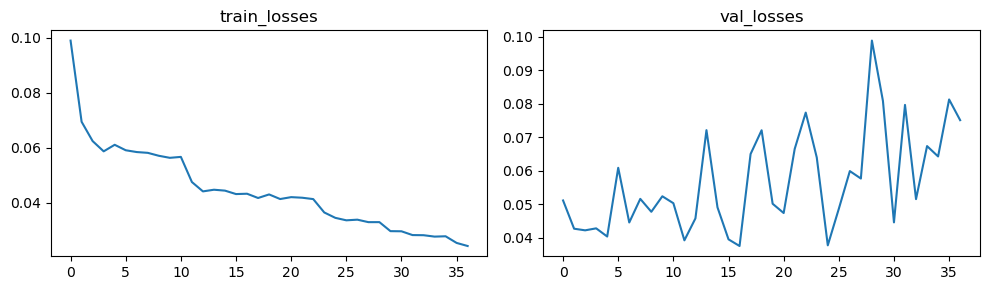

In [4]:
import matplotlib.pyplot as plt

train_metrics_array = np.array(train_metrics)
val_metrics_array = np.array(val_metrics)

# 绘制训练曲线
fig1 = plt.figure(figsize=(15, 5))

plt.subplot(1, 3, 1)
plt.plot(train_losses, label='Train Loss', linewidth=2)
plt.plot(val_losses, label='Val Loss', linewidth=2)
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.grid(True, alpha=0.3)
plt.title(f'{model_name} Training and Validation Loss')

plt.subplot(1, 3, 2)
plt.plot(train_metrics_array[:, 0], label='Train Accuracy', linewidth=2)
plt.plot(val_metrics_array[:, 0], label='Val Accuracy', linewidth=2)
plt.xlabel('Epoch')
plt.ylabel('Accuracy (%)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.title(f'{model_name} Training and Validation Accuracy')

# 绘制学习率变化
plt.subplot(1, 3, 3)
plt.semilogy(train_losses, label='Train Loss', alpha=0.7, linewidth=2)
plt.semilogy(val_losses, label='Val Loss', alpha=0.7, linewidth=2)
plt.xlabel('Epoch')
plt.ylabel('Loss (log scale)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.title(f'{model_name} Loss (Log Scale)')

plt.tight_layout()
save_dir = f'Test_results_{model_name}'
if not os.path.exists(save_dir):
    os.makedirs(save_dir)
plt.savefig(os.path.join(save_dir, 'model_train.png'), dpi=300, bbox_inches='tight')
plt.show()

fig2 = plt.figure(figsize=(15, 5))

plt.subplot(1, 3, 1)
plt.plot(train_metrics_array[:, 1], label='Train precision', linewidth=2)
plt.plot(val_metrics_array[:, 1], label='Val precision', linewidth=2)
plt.xlabel('Epoch')
plt.ylabel('precision')
plt.legend()
plt.grid(True, alpha=0.3)
plt.title(f'{model_name} Training and Validation precision')

plt.subplot(1, 3, 2)
plt.plot(train_metrics_array[:, 2], label='Train recall', linewidth=2)
plt.plot(val_metrics_array[:, 2], label='Val recall', linewidth=2)
plt.xlabel('Epoch')
plt.ylabel('recall')
plt.legend()
plt.grid(True, alpha=0.3)
plt.title(f'{model_name} Training and Validation recall')

# 绘制学习率变化
plt.subplot(1, 3, 3)
plt.semilogy(train_metrics_array[:, 3], label='Train F1', linewidth=2)
plt.semilogy(val_metrics_array[:, 3], label='Val F1', linewidth=2)
plt.xlabel('Epoch')
plt.ylabel('F1')
plt.legend()
plt.grid(True, alpha=0.3)
plt.title(f'{model_name} Training and Validation F1')

plt.tight_layout()
save_dir = f'Test_results_{model_name}'
if not os.path.exists(save_dir):
    os.makedirs(save_dir)
plt.savefig(os.path.join(save_dir, 'model_train2.png'), dpi=300, bbox_inches='tight')
plt.show()

fig3, (ax1, ax2) = plt.subplots(1, 2, figsize=(10, 3))
# 在第一个子图上绘制
ax1.plot(train_losses)
ax1.set_title('train_losses')

# 在第二个子图上绘制
ax2.plot(val_losses)
ax2.set_title('val_losses')

plt.tight_layout()  # 自动调整子图间距
plt.savefig(os.path.join(save_dir, 'model_train3.png'), dpi=300, bbox_inches='tight')
plt.show()